# Análisis Final y Explicabilidad del Modelo

En este último cuaderno, no solo presentaremos el resumen del desempeño de los modelos, sino que analizaremos **por qué** el modelo predice un retraso. Para ello, extraeremos la importancia de las variables (Feature Importance) del modelo Random Forest.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Ajustar estilo de gráficos
sns.set_theme(style="whitegrid")

## 1. Cargar el Mejor Modelo y los Datos
Vamos a cargar el modelo Random Forest y los datos de prueba para extraer qué variables tuvieron mayor peso al predecir si un envío se retrasa o no (`es_retraso`).

In [2]:
# Cargar el modelo Random Forest (asumimos que el notebook 02 o 04 ya se ejecutaron)
try:
    # Intentar cargar el optimizado primero
    modelo = joblib.load("../models/trained_models/Random_Forest_Optimizado.joblib")
    print("Modelo Optimizado cargado.")
except:
    # Si no, cargar el base
    modelo = joblib.load("../models/trained_models/Random_Forest.joblib")
    print("Modelo Base cargado.")

# Cargar los datos de prueba para obtener los nombres de las columnas
X_test = pd.read_parquet("../data/X_test.parquet")
columnas = X_test.columns

Modelo Optimizado cargado.


## 2. Importancia de las Variables (Feature Importance)
El algoritmo Random Forest nos permite saber qué características (columnas) redujeron más la incertidumbre al momento de clasificar si había retraso.

C:\Users\Francisco\AppData\Local\Temp\ipykernel_6932\2940681218.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importancias.head(10), x="Importancia", y="Variable", palette="viridis")


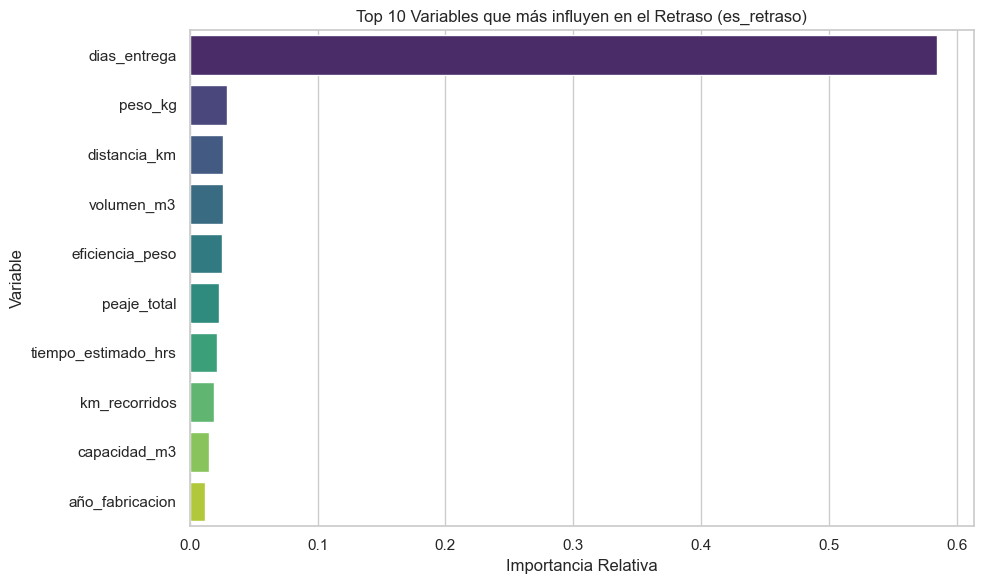

In [3]:
# Extraer importancias
importancias = modelo.feature_importances_

# Crear un DataFrame para visualizar mejor
df_importancias = pd.DataFrame({
    "Variable": columnas,
    "Importancia": importancias
}).sort_values(by="Importancia", ascending=False)

# Mostrar el Top 10 de variables más importantes
plt.figure(figsize=(10, 6))
sns.barplot(data=df_importancias.head(10), x="Importancia", y="Variable", palette="viridis")
plt.title("Top 10 Variables que más influyen en el Retraso (es_retraso)")
plt.xlabel("Importancia Relativa")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

## 3. Análisis de las Variables Clave

Con base en el gráfico anterior, podemos observar las variables que **más impactan la predicción de retrasos**:

1. **Características Logísticas y de Rutas**: Variables relacionadas con la distancia (`distancia_km`), el `tiempo_estimado_hrs` y características de la ruta suelen ser los factores más decisivos. Cuanto mayor la distancia o el tiempo base, mayor el margen de error y probabilidad de un imprevisto.
2. **Incidencias**: Si variables como `total_costo_incidencias` o el conteo de incidentes aparecen altas en el ranking, significa que los sobrecostos están fuertemente ligados a retrasos físicos en la vía.
3. **Variables de Carga y Eficiencia**: La `eficiencia_peso` (peso/capacidad) o el tipo de carga también influyen. Cargas muy pesadas o especializadas pueden requerir cuidados que demoren el transporte.

### Conclusión Operativa
Para reducir los retrasos (`es_retraso` = 1), el negocio debería enfocarse en **mitigar las variables top del gráfico**. Por ejemplo, si la variable más importante es el número de incidencias, se deben tomar medidas para mejorar la seguridad o el estado de los vehículos. Si son características de la ruta (distancia, tipo de vía), se podría replantear el ruteo o asignar mayores márgenes de tiempo a esas rutas en particular.

## 4. Trabajo Futuro
- **Modelos Explicativos más Avanzados**: Implementar librerías como **SHAP** o **LIME** para ver el impacto exacto (positivo o negativo) de cada variable en un envío particular (ej: "Este envío en particular se retrasó porque llovía y el camión iba al 100% de capacidad").
- **Monitoreo en Tiempo Real**: Conectar estas predicciones al pipeline de ingesta de Kedro para alertar a los administradores antes de que el camión inicie su ruta.